In [1]:
!pip install -q stardist csbdeep scikit-image scikit-learn imageio openpyxl tqdm matplotlib

In [30]:
# Imports, paths, reproducibility
import os
import glob
import random
import numpy as np
import pandas as pd
import imageio.v2 as imageio
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from csbdeep.utils import normalize

import tensorflow as tf
from stardist.models import Config2D, StarDist2D

# Paths
DATA_DIR = "/home/dmengji1/spherical-data-code"
EXCEL_PATH = os.path.join(DATA_DIR, "mask_circle.xlsx")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

OUT_DIR = os.path.join(DATA_DIR, "stardist_outputs")
MODEL_DIR = os.path.join(OUT_DIR, "models")
PRED_DIR = os.path.join(OUT_DIR, "predictions")

VAL_INST_DIR = os.path.join(PRED_DIR, "val_instances")
VAL_MERGE_DIR = os.path.join(PRED_DIR, "val_merged")
TEST_INST_DIR = os.path.join(PRED_DIR, "test_instances")
TEST_MERGE_DIR = os.path.join(PRED_DIR, "test_merged")

TEST_DIR = "/home/dmengji1/spherical-data-code/test"
GT_MASK_DIR = "/home/dmengji1/spherical-data-code/test-masks"
PRED_INST_DIR = "/home/dmengji1/spherical-data-code/stardist_outputs/predictions/test_instances"
PRED_MERGE_DIR = "/home/dmengji1/spherical-data-code/stardist_outputs/predictions/test_merged"

for d in [OUT_DIR, MODEL_DIR, PRED_DIR, VAL_INST_DIR, VAL_MERGE_DIR, TEST_INST_DIR, TEST_MERGE_DIR]:
    os.makedirs(d, exist_ok=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory growth
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", gpus)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Load Excel and prepare image-level table

df = pd.read_excel(EXCEL_PATH, header=0)
df.columns = df.columns.str.strip().str.lower()

# force id to string
df["id"] = df["id"].astype(str).str.replace(r"\.0$", "", regex=True)

print(df.head())
print(df.columns.tolist())
print(df["cell_type"].value_counts())
print("Unique image ids:", df["id"].nunique())

image_df = (
    df.groupby("id", as_index=False)
      .agg({
          "cell_type": "first",
          "width": "first",
          "height": "first",
          "sample_id": "first",
          "plate_time": "first",
          "sample_date": "first",
          "elapsed_timedelta": "first",
      })
)

print(image_df.head())

             id                                         annotation  width  \
0  0030fd0e6378  118145 6 118849 7 119553 8 120257 8 120961 9 1...    704   
1  0030fd0e6378  189036 1 189739 3 190441 6 191144 7 191848 8 1...    704   
2  0030fd0e6378  173567 3 174270 5 174974 5 175678 6 176382 7 1...    704   
3  0030fd0e6378  196723 4 197427 6 198130 7 198834 8 199538 8 2...    704   
4  0030fd0e6378  167818 3 168522 5 169225 7 169928 8 170632 9 1...    704   

   height cell_type plate_time          sample_date  \
0     520    shsy5y  11h30m00s  2019-06-16 00:00:00   
1     520    shsy5y  11h30m00s  2019-06-16 00:00:00   
2     520    shsy5y  11h30m00s  2019-06-16 00:00:00   
3     520    shsy5y  11h30m00s  2019-06-16 00:00:00   
4     520    shsy5y  11h30m00s  2019-06-16 00:00:00   

                            sample_id elapsed_timedelta  
0  shsy5y[diff]_E10-4_Vessel-714_Ph_3   0 days 11:30:00  
1  shsy5y[diff]_E10-4_Vessel-714_Ph_3   0 days 11:30:00  
2  shsy5y[diff]_E10-4_Vessel-714

In [31]:
# Helper functions
def find_image_path(image_id, folder):
    image_id = str(image_id).replace(".0", "")
    exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]
    for ext in exts:
        p = os.path.join(folder, image_id + ext)
        if os.path.exists(p):
            return p

    matches = glob.glob(os.path.join(folder, image_id + ".*"))
    if len(matches) > 0:
        return matches[0]

    raise FileNotFoundError(f"Could not find image for id={image_id} in {folder}")


def rle_decode_sartorius(rle_str, height, width):
    """
    Sartorius RLE decoder.
    Returns a binary mask of shape (H, W), values 0/1.
    This matches the decoder you said works best.
    """
    if pd.isna(rle_str) or str(rle_str).strip() == "":
        return np.zeros((height, width), dtype=np.uint8)

    s = np.asarray(str(rle_str).split(), dtype=np.int64)
    starts = s[0::2] - 1
    lengths = s[1::2]
    ends = starts + lengths

    flat = np.zeros(height * width, dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        flat[lo:hi] = 1

    return flat.reshape((width, height), order="F").T


def build_instance_mask(image_id, df):
    """
    Build one labeled instance mask per image.
    background = 0
    each cell = 1, 2, 3, ...
    """
    image_id = str(image_id).replace(".0", "")
    rows = df[df["id"] == image_id]

    h = int(rows["height"].iloc[0])
    w = int(rows["width"].iloc[0])

    inst = np.zeros((h, w), dtype=np.uint16)

    label = 1
    for _, row in rows.iterrows():
        rle = row["annotation"]
        m = rle_decode_sartorius(rle, h, w)
        if m.sum() == 0:
            continue
        inst[(m > 0) & (inst == 0)] = label
        label += 1

    return inst


def read_image(image_id, folder):
    """
    Read image and convert to grayscale if needed.
    Returns float32 image with original size.
    """
    path = find_image_path(image_id, folder)
    img = imageio.imread(path)

    if img.ndim == 3:
        if img.shape[-1] == 3:
            img = img.mean(axis=-1)
        else:
            img = img[..., 0]

    return img.astype(np.float32), path


def to_float01(img):
    return normalize(img, 1, 99.8, axis=None)


def merged_mask_from_instances(inst_mask):
    return (inst_mask > 0).astype(np.uint8)


def iou_binary(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    inter = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return 1.0 if union == 0 else inter / union


def mean_iou_over_images(y_true_list, y_pred_list):
    vals = [iou_binary(t, p) for t, p in zip(y_true_list, y_pred_list)]
    return float(np.mean(vals)), vals


def save_label_png(mask, path):
    imageio.imwrite(path, mask.astype(np.uint16))


def save_binary_png(mask, path):
    imageio.imwrite(path, (mask > 0).astype(np.uint8) * 255)

def find_mask_path(image_id, mask_dir):
    exts = [".png", ".tif", ".tiff", ".jpg", ".jpeg", ".bmp"]
    candidates = []

    for ext in exts:
        candidates.append(os.path.join(mask_dir, image_id + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_mask" + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_merged" + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_instances" + ext))

    for p in candidates:
        if os.path.exists(p):
            return p

    matches = glob.glob(os.path.join(mask_dir, image_id + ".*"))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find mask for {image_id} in {mask_dir}")


def load_mask(path):
    m = imageio.imread(path)
    if m.ndim == 3:
        m = m[..., 0]
    return m

In [5]:
# Stratified train/val split by cell_type

X = image_df["id"].astype(str).to_numpy()
y = image_df["cell_type"].astype(str).to_numpy()

train_ids, val_ids = train_test_split(
    X,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

train_ids = list(train_ids)
val_ids = list(val_ids)

print("Train images:", len(train_ids))
print("Val images:", len(val_ids))
print("Overlap:", len(set(train_ids) & set(val_ids)))

print("\nTrain cell type distribution:")
print(image_df[image_df["id"].isin(train_ids)]["cell_type"].value_counts())

print("\nVal cell type distribution:")
print(image_df[image_df["id"].isin(val_ids)]["cell_type"].value_counts())

Train images: 447
Val images: 112
Overlap: 0

Train cell type distribution:
cell_type
cort      250
shsy5y    110
astro      87
Name: count, dtype: int64

Val cell type distribution:
cell_type
cort      63
shsy5y    27
astro     22
Name: count, dtype: int64


In [6]:
# Load train/val images and masks

X_train, Y_train = [], []
X_val, Y_val = [], []

print("Loading training data...")
for image_id in tqdm(train_ids):
    img, _ = read_image(image_id, TRAIN_DIR)
    inst = build_instance_mask(image_id, df)
    X_train.append(to_float01(img))
    Y_train.append(inst)

print("Loading validation data...")
for image_id in tqdm(val_ids):
    img, _ = read_image(image_id, TRAIN_DIR)
    inst = build_instance_mask(image_id, df)
    X_val.append(to_float01(img))
    Y_val.append(inst)

print("Loaded:", len(X_train), "train and", len(X_val), "val images")
print("Example shapes:", X_train[0].shape, Y_train[0].shape)

Loading training data...


  0%|          | 0/447 [00:00<?, ?it/s]

Loading validation data...


  0%|          | 0/112 [00:00<?, ?it/s]

Loaded: 447 train and 112 val images
Example shapes: (520, 704) (520, 704)


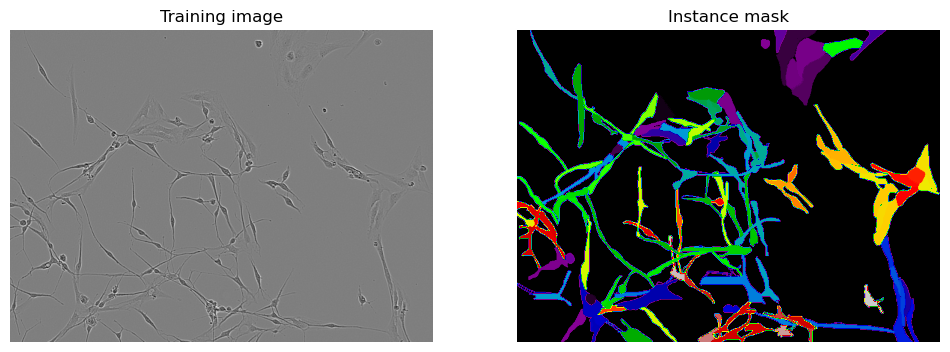

Max label: 128
Foreground pixels: 76029


In [7]:
# Sanity check on one training sample

idx = 0
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_train[idx], cmap="gray")
plt.title("Training image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Y_train[idx], cmap="nipy_spectral")
plt.title("Instance mask")
plt.axis("off")

plt.show()

print("Max label:", Y_train[idx].max())
print("Foreground pixels:", np.sum(Y_train[idx] > 0))

In [8]:
# StarDist 2D model

def augmenter(x, y):
    # flips
    if np.random.rand() > 0.5:
        x = np.flip(x, axis=0)
        y = np.flip(y, axis=0)
    if np.random.rand() > 0.5:
        x = np.flip(x, axis=1)
        y = np.flip(y, axis=1)

    # 90-degree rotations
    k = np.random.randint(0, 4)
    x = np.rot90(x, k)
    y = np.rot90(y, k)

    # mild intensity scaling
    x = x * (0.9 + 0.2 * np.random.rand())
    return x, y

conf = Config2D(
    n_rays=32,
    grid=(1, 1),
    use_gpu=False,          # avoids gputools issue
    n_channel_in=1,
    train_patch_size=(256, 256),
    train_batch_size=2,
    train_epochs=300,
    train_steps_per_epoch=max(100, len(X_train) // 2),
    train_learning_rate=3e-4,
    train_reduce_lr={"factor": 0.5, "patience": 10},
)

model_name = "sartorius_stardist_2d_scratch"
model = StarDist2D(conf, name=model_name, basedir=MODEL_DIR)

print("Model created.")
print(model)

base_model.py (203): output path for model already exists, files may be overwritten: /home/dmengji1/spherical-data-code/stardist_outputs/models/sartorius_stardist_2d_scratch
2026-05-03 19:39:19.316108: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18226 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB MIG 2g.20gb, pci bus id: 0000:01:00.0, compute capability: 8.0


Using default values: prob_thresh=0.5, nms_thresh=0.4.
Model created.
StarDist2D(sartorius_stardist_2d_scratch): YXC → YXC
├─ Directory: /home/dmengji1/spherical-data-code/stardist_outputs/models/sartorius_stardist_2d_scratch
└─ Config2D(n_dim=2, axes='YXC', n_channel_in=1, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(1, 1), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=(3, 3), unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=(2, 2), unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_expansion=2, unet_prefix='', net_conv_after_unet=128, net_input_shape=(None, None, 1), net_mask_shape=(None, None, 1), train_shape_completion=False, train_completion_crop=32, train_patch_size=(256, 256), train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights

In [9]:
# Train
history = model.train(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    augmenter=augmenter,
    epochs=conf.train_epochs,
    steps_per_epoch=conf.train_steps_per_epoch
)

final_weights_path = os.path.join(MODEL_DIR, "final_weights.h5")
model.keras_model.save_weights(final_weights_path)
print("Saved final weights to:", final_weights_path)

Epoch 1/300


2026-05-03 19:39:53.856252: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-05-03 19:40:00.915662: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-03 19:40:13.795590: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-03 19:41:13.068067: I external/local_xla/xla/service/service.cc:168] XLA service 0x15515dc25250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-03 19:41:13.068124: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB MIG 2g.20gb, Compute Capability 8.0
2026-05-03 19:41:13.235032: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777862478.865551  729988 device

223/223 [==============================] - 267s 141ms/step - loss: 1.4334 - prob_loss: 0.2076 - dist_loss: 6.1292 - prob_kld: 0.1674 - dist_relevant_mae: 6.1286 - dist_relevant_mse: 95.7567 - dist_dist_iou_metric: 0.2525 - val_loss: 1.2443 - val_prob_loss: 0.1420 - val_dist_loss: 5.5115 - val_prob_kld: 0.1003 - val_dist_relevant_mae: 5.5108 - val_dist_relevant_mse: 83.8135 - val_dist_dist_iou_metric: 0.3072 - lr: 3.0000e-04
Epoch 2/300
223/223 [==============================] - 10s 44ms/step - loss: 1.1800 - prob_loss: 0.1501 - dist_loss: 5.1497 - prob_kld: 0.1092 - dist_relevant_mae: 5.1490 - dist_relevant_mse: 69.2768 - dist_dist_iou_metric: 0.3247 - val_loss: 1.2530 - val_prob_loss: 0.1348 - val_dist_loss: 5.5911 - val_prob_kld: 0.0932 - val_dist_relevant_mae: 5.5905 - val_dist_relevant_mse: 86.4374 - val_dist_dist_iou_metric: 0.2820 - lr: 3.0000e-04
Epoch 3/300
223/223 [==============================] - 10s 45ms/step - loss: 1.1309 - prob_loss: 0.1313 - dist_loss: 4.9979 - prob_kld

In [10]:
# Validation inference and IoU

def run_val_eval(prob_thresh=0.5, nms_thresh=0.4):
    val_pred_instances = []
    val_pred_merged = []
    val_true_merged = []

    for image_id, x, y in tqdm(list(zip(val_ids, X_val, Y_val)), total=len(X_val)):
        labels, details = model.predict_instances(
            x,
            prob_thresh=prob_thresh,
            nms_thresh=nms_thresh
        )
        val_pred_instances.append(labels.astype(np.uint16))
        val_pred_merged.append(merged_mask_from_instances(labels))
        val_true_merged.append(merged_mask_from_instances(y))

    mean_val_iou, per_image_ious = mean_iou_over_images(val_true_merged, val_pred_merged)
    print(f"Validation mean IoU (merged masks): {mean_val_iou:.5f}")

    return mean_val_iou, per_image_ious, val_pred_instances, val_pred_merged, val_true_merged


PROB_THRESH = 0.5
NMS_THRESH = 0.4

mean_val_iou, per_image_ious, val_pred_instances, val_pred_merged, val_true_merged = run_val_eval(
    prob_thresh=PROB_THRESH,
    nms_thresh=NMS_THRESH
)

# save validation predictions
for image_id, inst_mask, merged_mask in zip(val_ids, val_pred_instances, val_pred_merged):
    save_label_png(inst_mask, os.path.join(VAL_INST_DIR, f"{image_id}_instances.png"))
    save_binary_png(merged_mask, os.path.join(VAL_MERGE_DIR, f"{image_id}_merged.png"))

print("Saved validation masks.")

  0%|          | 0/112 [00:00<?, ?it/s]

Validation mean IoU (merged masks): 0.48616
Saved validation masks.


In [14]:
# Threshold tuning on validation set

prob_grid = [0.1, 0.2, 0.3, 0.4, 0.5]
nms_grid = [0.2, 0.3, 0.4, 0.5, 0.6]

best_iou = -1
best_params = None

for p in prob_grid:
    for n in nms_grid:
        ious = []
        fg_fracs = []
        for x, y in zip(X_val, Y_val):
            labels, _ = model.predict_instances(
                x,
                prob_thresh=p,
                nms_thresh=n
            )
            pred = (labels > 0).astype(np.uint8)
            true = (y > 0).astype(np.uint8)

            inter = np.logical_and(pred, true).sum()
            union = np.logical_or(pred, true).sum()
            iou = 1.0 if union == 0 else inter / union

            ious.append(iou)
            fg_fracs.append(pred.mean())

        mean_iou = float(np.mean(ious))
        mean_fg = float(np.mean(fg_fracs))
        print(f"prob={p:.1f}, nms={n:.1f} -> IoU={mean_iou:.5f}, pred_fg_frac={mean_fg:.4f}")

        if mean_iou > best_iou:
            best_iou = mean_iou
            best_params = (p, n)

print("\nBest validation IoU:", best_iou)
print("Best thresholds:", best_params)

prob=0.1, nms=0.2 -> IoU=0.49114, pred_fg_frac=0.0974
prob=0.1, nms=0.3 -> IoU=0.49397, pred_fg_frac=0.1017
prob=0.1, nms=0.4 -> IoU=0.49682, pred_fg_frac=0.1054
prob=0.1, nms=0.5 -> IoU=0.49899, pred_fg_frac=0.1091
prob=0.1, nms=0.6 -> IoU=0.49984, pred_fg_frac=0.1123
prob=0.2, nms=0.2 -> IoU=0.51393, pred_fg_frac=0.0852
prob=0.2, nms=0.3 -> IoU=0.51736, pred_fg_frac=0.0878
prob=0.2, nms=0.4 -> IoU=0.52016, pred_fg_frac=0.0900
prob=0.2, nms=0.5 -> IoU=0.52309, pred_fg_frac=0.0921
prob=0.2, nms=0.6 -> IoU=0.52488, pred_fg_frac=0.0942
prob=0.3, nms=0.2 -> IoU=0.51949, pred_fg_frac=0.0763
prob=0.3, nms=0.3 -> IoU=0.52199, pred_fg_frac=0.0781
prob=0.3, nms=0.4 -> IoU=0.52469, pred_fg_frac=0.0795
prob=0.3, nms=0.5 -> IoU=0.52673, pred_fg_frac=0.0807
prob=0.3, nms=0.6 -> IoU=0.52877, pred_fg_frac=0.0819
prob=0.4, nms=0.2 -> IoU=0.51019, pred_fg_frac=0.0663
prob=0.4, nms=0.3 -> IoU=0.51314, pred_fg_frac=0.0675
prob=0.4, nms=0.4 -> IoU=0.51485, pred_fg_frac=0.0683
prob=0.4, nms=0.5 -> IoU=0.5

In [15]:
# Re-evaluate validation with best thresholds

PROB_THRESH, NMS_THRESH = best_params

mean_val_iou, per_image_ious, val_pred_instances, val_pred_merged, val_true_merged = run_val_eval(
    prob_thresh=PROB_THRESH,
    nms_thresh=NMS_THRESH
)

print("Final validation IoU:", mean_val_iou)
print("Chosen thresholds:", PROB_THRESH, NMS_THRESH)

  0%|          | 0/112 [00:00<?, ?it/s]

Validation mean IoU (merged masks): 0.52877
Final validation IoU: 0.5287671914174251
Chosen thresholds: 0.3 0.6


In [16]:
# Predict on test images and save PNGs

test_files = sorted(glob.glob(os.path.join(TEST_DIR, "*")))
test_ids = [os.path.splitext(os.path.basename(p))[0] for p in test_files]

print("Test images found:", len(test_ids))

for image_id in tqdm(test_ids, desc="Predicting test"):
    img, _ = read_image(image_id, TEST_DIR)
    img = to_float01(img)

    labels, details = model.predict_instances(
        img,
        prob_thresh=PROB_THRESH,
        nms_thresh=NMS_THRESH
    )

    merged = merged_mask_from_instances(labels)

    save_label_png(labels, os.path.join(TEST_INST_DIR, f"{image_id}_instances.png"))
    save_binary_png(merged, os.path.join(TEST_MERGE_DIR, f"{image_id}_merged.png"))

print("Saved test instance masks to:", TEST_INST_DIR)
print("Saved test merged masks to:", TEST_MERGE_DIR)

Test images found: 3


Predicting test:   0%|          | 0/3 [00:00<?, ?it/s]

Saved test instance masks to: /home/dmengji1/spherical-data-code/stardist_outputs/predictions/test_instances
Saved test merged masks to: /home/dmengji1/spherical-data-code/stardist_outputs/predictions/test_merged


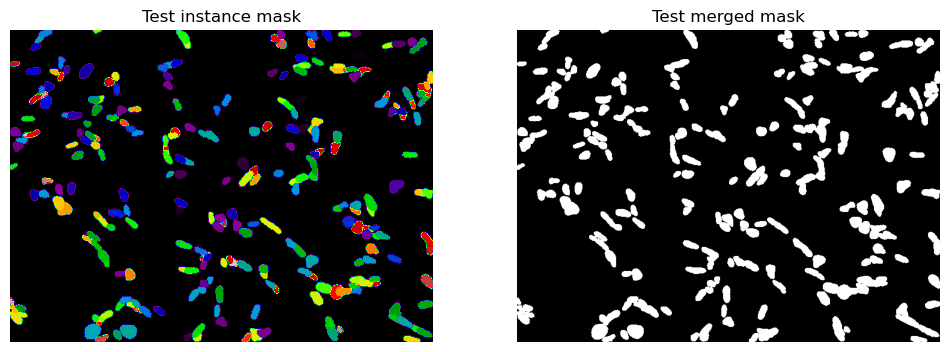

Instance mask dtype: uint16 max label: 276
Merged mask dtype: uint8 unique: [  0 255]


In [17]:
# Quick test visualization

sample_id = test_ids[0]
inst = imageio.imread(os.path.join(TEST_INST_DIR, f"{sample_id}_instances.png"))
merge = imageio.imread(os.path.join(TEST_MERGE_DIR, f"{sample_id}_merged.png"))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(inst, cmap="nipy_spectral")
plt.title("Test instance mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(merge, cmap="gray")
plt.title("Test merged mask")
plt.axis("off")

plt.show()

print("Instance mask dtype:", inst.dtype, "max label:", inst.max())
print("Merged mask dtype:", merge.dtype, "unique:", np.unique(merge))

In [18]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
os.makedirs(PRED_INST_DIR, exist_ok=True)
os.makedirs(PRED_MERGE_DIR, exist_ok=True)

def merged_mask_from_instances(inst_mask):
    return (inst_mask > 0).astype(np.uint8)

def iou_binary(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    inter = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return 1.0 if union == 0 else inter / union

def find_mask_path(image_id, mask_dir):
    exts = [".png", ".tif", ".tiff", ".jpg", ".jpeg", ".bmp"]
    candidates = []

    for ext in exts:
        candidates.append(os.path.join(mask_dir, image_id + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_mask" + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_merged" + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_instances" + ext))

    for p in candidates:
        if os.path.exists(p):
            return p

    matches = glob.glob(os.path.join(mask_dir, image_id + ".*"))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find mask for {image_id} in {mask_dir}")

def load_mask(path):
    m = imageio.imread(path)
    if m.ndim == 3:
        m = m[..., 0]
    return m

In [19]:
test_files = sorted(glob.glob(os.path.join(TEST_DIR, "*")))
test_ids = [os.path.splitext(os.path.basename(p))[0] for p in test_files]

print("Number of test images:", len(test_ids))

ious = []
per_image_results = []

for image_id in tqdm(test_ids, desc="Testing and computing IoU"):
    # load image
    img, _ = read_image(image_id, TEST_DIR)
    img = to_float01(img)

    # predict with StarDist
    pred_labels, details = model.predict_instances(
        img,
        prob_thresh=PROB_THRESH,
        nms_thresh=NMS_THRESH
    )

    pred_merged = merged_mask_from_instances(pred_labels)

    # load ground truth mask
    gt_path = find_mask_path(image_id, GT_MASK_DIR)
    gt_mask = load_mask(gt_path)

    # convert ground truth to binary foreground mask
    gt_merged = (gt_mask > 0).astype(np.uint8)

    # compute IoU
    iou = iou_binary(gt_merged, pred_merged)
    ious.append(iou)
    per_image_results.append((image_id, iou))

    # save predictions
    imageio.imwrite(os.path.join(PRED_INST_DIR, f"{image_id}_instances.png"), pred_labels.astype(np.uint16))
    imageio.imwrite(os.path.join(PRED_MERGE_DIR, f"{image_id}_merged.png"), (pred_merged * 255).astype(np.uint8))

mean_iou = float(np.mean(ious))
median_iou = float(np.median(ious))
min_iou = float(np.min(ious))
max_iou = float(np.max(ious))

print("Mean IoU:", mean_iou)
print("Median IoU:", median_iou)
print("Min IoU:", min_iou)
print("Max IoU:", max_iou)

Number of test images: 3


Testing and computing IoU:   0%|          | 0/3 [00:00<?, ?it/s]

Mean IoU: 0.4600296893567166
Median IoU: 0.4412665641865736
Min IoU: 0.4344062851816432
Max IoU: 0.504416218701933



===== Processing 7ae19de7bc2a =====
IoU: 0.4344062851816432
Pred max label: 276
GT foreground pixels: 67265
Pred foreground pixels: 13062885


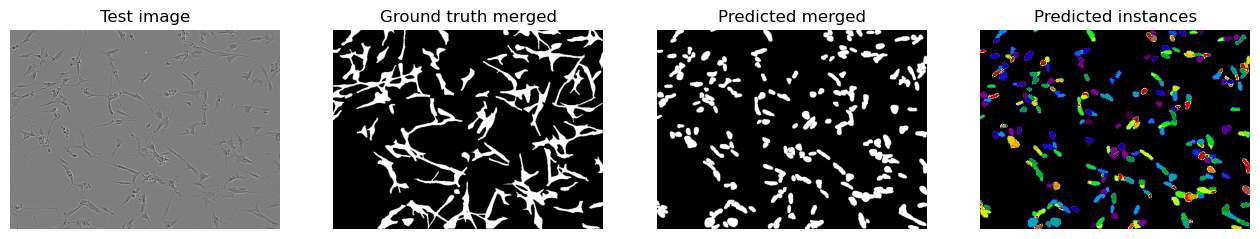


===== Processing d48ec7815252 =====
IoU: 0.504416218701933
Pred max label: 60
GT foreground pixels: 58620
Pred foreground pixels: 9244515


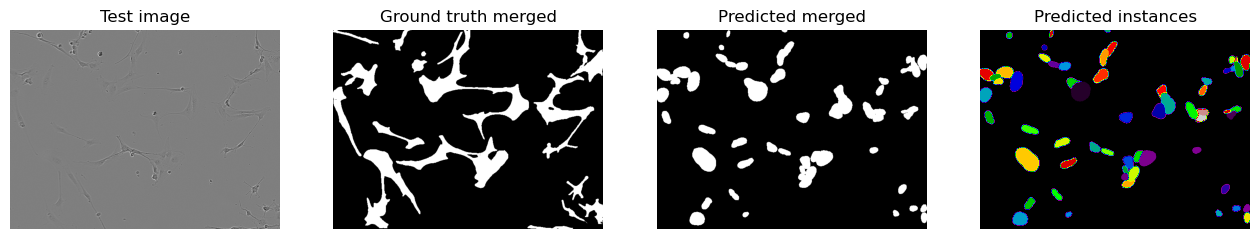


===== Processing d8bfd1dafdc4 =====
IoU: 0.4412665641865736
Pred max label: 124
GT foreground pixels: 69878
Pred foreground pixels: 14935860


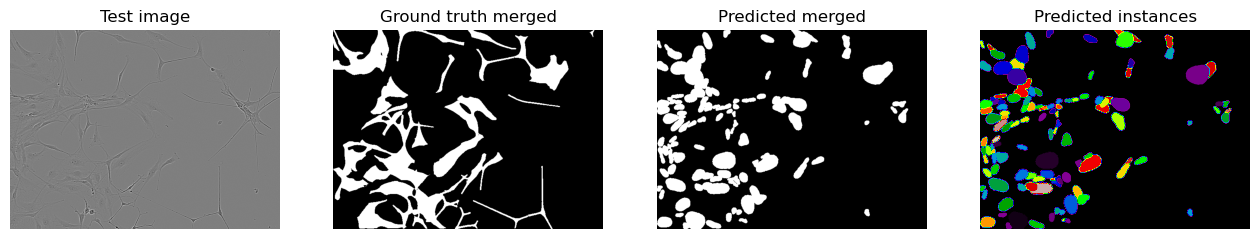


===== FINAL RESULTS =====
Mean IoU: 0.4600296893567166
All IoUs: [0.4344062851816432, 0.504416218701933, 0.4412665641865736]

Saved results to: /home/dmengji1/spherical-data-code/stardist_outputs/test_iou_results.csv
             id       iou
0  7ae19de7bc2a  0.434406
1  d48ec7815252  0.504416
2  d8bfd1dafdc4  0.441267


In [29]:
import pandas as pd

ious = []
per_image_results = []

for sample_id in test_ids:
    print(f"\n===== Processing {sample_id} =====")

    # load image
    img, _ = read_image(sample_id, TEST_DIR)
    img = to_float01(img)

    # load predictions
    pred_inst = imageio.imread(os.path.join(PRED_INST_DIR, f"{sample_id}_instances.png"))
    pred_merge = imageio.imread(os.path.join(PRED_MERGE_DIR, f"{sample_id}_merged.png"))

    # load ground truth
    gt_path = find_mask_path(sample_id, GT_MASK_DIR)
    gt_mask = load_mask(gt_path)
    gt_merge = (gt_mask > 0).astype(np.uint8)

    # compute IoU
    iou = iou_binary(gt_merge, pred_merge)
    ious.append(iou)
    per_image_results.append((sample_id, iou))

    # print stats
    print("IoU:", iou)
    print("Pred max label:", pred_inst.max())
    print("GT foreground pixels:", gt_merge.sum())
    print("Pred foreground pixels:", pred_merge.sum())

    # visualize
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Test image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt_merge, cmap="gray")
    plt.title("Ground truth merged")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_merge, cmap="gray")
    plt.title("Predicted merged")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(pred_inst, cmap="nipy_spectral")
    plt.title("Predicted instances")
    plt.axis("off")

    plt.show()

# overall stats
mean_iou = float(np.mean(ious))
print("\n===== FINAL RESULTS =====")
print("Mean IoU:", mean_iou)
print("All IoUs:", ious)

# save CSV
results_df = pd.DataFrame(per_image_results, columns=["id", "iou"])
csv_path = "/home/dmengji1/spherical-data-code/stardist_outputs/test_iou_results.csv"
results_df.to_csv(csv_path, index=False)

print("\nSaved results to:", csv_path)
print(results_df)


===== Processing 7ae19de7bc2a =====
IoU (GT vs StarDist): 0.4344062851816432
GT foreground pixels: 67265
StarDist foreground pixels: 51227
Cellpose foreground pixels: 18997
Combined foreground pixels: 60881


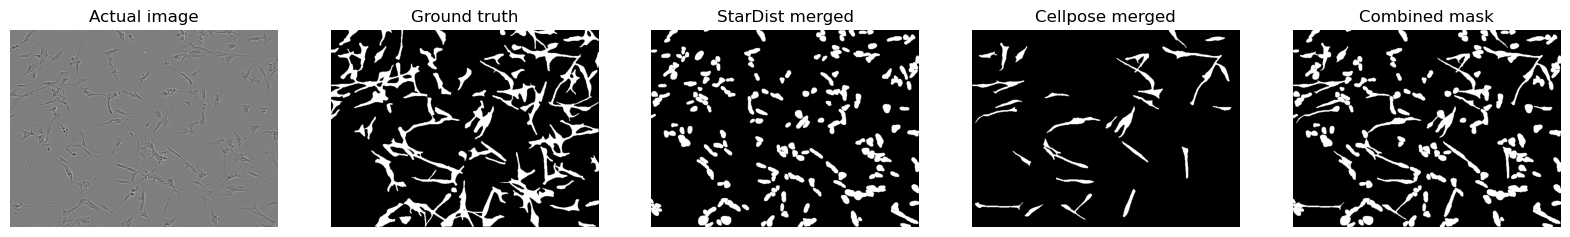


===== Processing d48ec7815252 =====
IoU (GT vs StarDist): 0.504416218701933
GT foreground pixels: 58620
StarDist foreground pixels: 36253
Cellpose foreground pixels: 25176
Combined foreground pixels: 49858


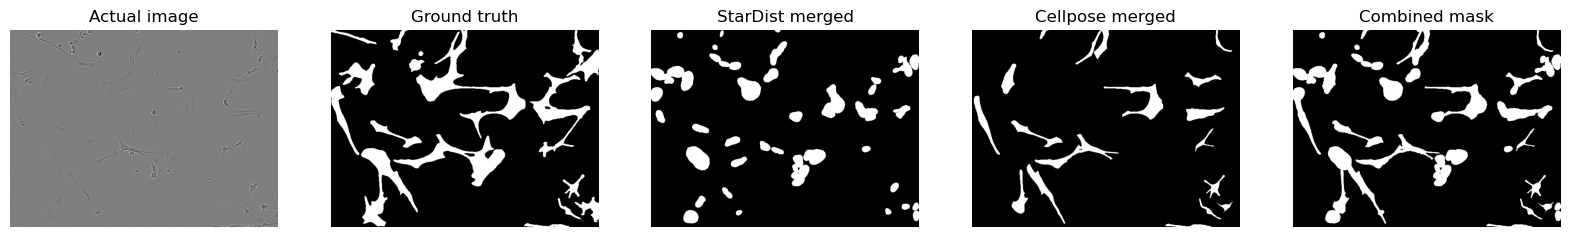


===== Processing d8bfd1dafdc4 =====
IoU (GT vs StarDist): 0.4412665641865736
GT foreground pixels: 69878
StarDist foreground pixels: 58572
Cellpose foreground pixels: 30766
Combined foreground pixels: 73414


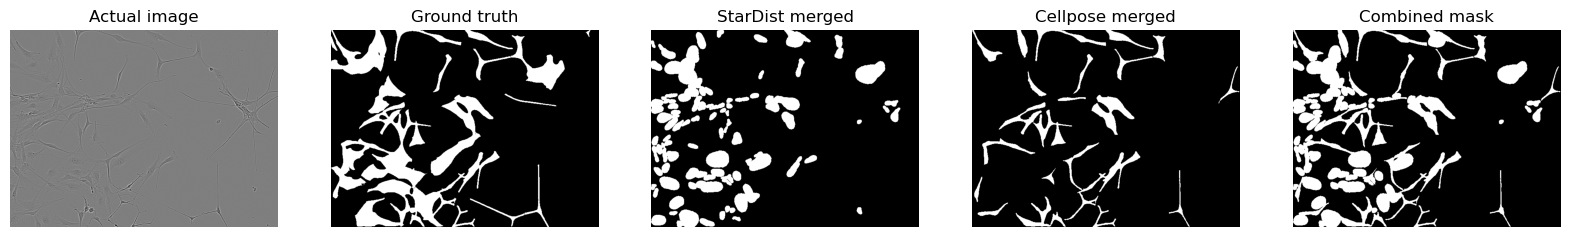


===== FINAL RESULTS =====
Mean IoU (GT vs StarDist): 0.4600296893567166
All IoUs: [0.4344062851816432, 0.504416218701933, 0.4412665641865736]
Saved results to: /home/dmengji1/spherical-data-code/stardist_outputs/test_iou_results.csv
             id       iou
0  7ae19de7bc2a  0.434406
1  d48ec7815252  0.504416
2  d8bfd1dafdc4  0.441267


In [34]:
import os
import glob
import numpy as np
import pandas as pd
import imageio.v2 as imageio
import matplotlib.pyplot as plt

# Paths
TEST_DIR = "/home/dmengji1/spherical-data-code/test"
GT_MASK_DIR = "/home/dmengji1/spherical-data-code/test-masks"

STARDIST_DIR = "/home/dmengji1/spherical-data-code/stardist_outputs/predictions/test_merged"
CELLPOSE_DIR = "/home/dmengji1/spherical-data-code/cellpose-output-masks"
COMBINED_DIR = "/home/dmengji1/spherical-data-code/combined-masks"

def find_mask_path(image_id, mask_dir):
    exts = [".png", ".tif", ".tiff", ".jpg", ".jpeg", ".bmp"]
    candidates = []

    for ext in exts:
        candidates.append(os.path.join(mask_dir, image_id + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_merged" + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_instances" + ext))
        candidates.append(os.path.join(mask_dir, image_id + "_mask" + ext))

    for p in candidates:
        if os.path.exists(p):
            return p

    matches = glob.glob(os.path.join(mask_dir, image_id + ".*"))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find mask for {image_id} in {mask_dir}")

def load_mask(path):
    m = imageio.imread(path)
    if m.ndim == 3:
        m = m[..., 0]
    return m

def iou_binary(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    inter = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return 1.0 if union == 0 else inter / union

test_files = sorted(glob.glob(os.path.join(TEST_DIR, "*")))
test_ids = [os.path.splitext(os.path.basename(p))[0] for p in test_files]

ious = []
per_image_results = []

for sample_id in test_ids:
    print(f"\n===== Processing {sample_id} =====")

    # load actual image
    img, _ = read_image(sample_id, TEST_DIR)
    img = to_float01(img)

    # load ground truth
    gt_path = find_mask_path(sample_id, GT_MASK_DIR)
    gt_mask = load_mask(gt_path)
    gt_merge = (gt_mask > 0).astype(np.uint8)

    # load StarDist prediction (combined/merged mask)
    stardist_path = find_mask_path(sample_id, STARDIST_DIR)
    stardist_merge = load_mask(stardist_path)
    stardist_merge = (stardist_merge > 0).astype(np.uint8)

    # load Cellpose prediction (combined/merged mask)
    cellpose_path = find_mask_path(sample_id, CELLPOSE_DIR)
    cellpose_merge = load_mask(cellpose_path)
    cellpose_merge = (cellpose_merge > 0).astype(np.uint8)

    # load final combined mask
    combined_path = find_mask_path(sample_id, COMBINED_DIR)
    combined_mask = load_mask(combined_path)
    combined_mask = (combined_mask > 0).astype(np.uint8)

    # IoU for StarDist vs GT
    iou = iou_binary(gt_merge, stardist_merge)
    ious.append(iou)
    per_image_results.append((sample_id, iou))

    print("IoU (GT vs StarDist):", iou)
    print("GT foreground pixels:", gt_merge.sum())
    print("StarDist foreground pixels:", stardist_merge.sum())
    print("Cellpose foreground pixels:", cellpose_merge.sum())
    print("Combined foreground pixels:", combined_mask.sum())

    # visualize
    plt.figure(figsize=(20, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Actual image")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(gt_merge, cmap="gray")
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(stardist_merge, cmap="gray")
    plt.title("StarDist merged")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(cellpose_merge, cmap="gray")
    plt.title("Cellpose merged")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(combined_mask, cmap="gray")
    plt.title("Combined mask")
    plt.axis("off")

    plt.show()

mean_iou = float(np.mean(ious))
print("\n===== FINAL RESULTS =====")
print("Mean IoU (GT vs StarDist):", mean_iou)
print("All IoUs:", ious)

results_df = pd.DataFrame(per_image_results, columns=["id", "iou"])
csv_path = "/home/dmengji1/spherical-data-code/stardist_outputs/test_iou_results.csv"
results_df.to_csv(csv_path, index=False)

print("Saved results to:", csv_path)
print(results_df)